# MedSafe — CatBoost Interaction Classifier

This notebook trains a **CatBoostClassifier** on the full DDInter dataset to predict drug-drug interaction severity.

**Why CatBoost?**
- Handles categorical features (drug names) natively — no one-hot encoding needed.
- Robust to class imbalance with built-in class weights.
- Fast training, excellent out-of-the-box accuracy.

**Inputs** — place all `ddinter_downloads_code_*.csv` files in `../app/data/`  
**Outputs** — saved to `../ml/artifacts/`:
- `catboost_interaction.cbm` — trained model
- `label_encoder.joblib` — maps class indices ↔ level strings
- `drug_encoder.joblib` — maps drug_name → DDInterID (for inference on unseen drugs)


## 1. Imports & paths

In [3]:
import glob
import re
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR      = Path('../app/data')
ARTIFACTS_DIR = Path('../ml/artifacts')
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
print('Data dir:', DATA_DIR.resolve())
print('Artifacts dir:', ARTIFACTS_DIR.resolve())

Data dir: C:\Users\sasas\Desktop\Projects\Biovatech Hackathon\medsafe_api\app\data
Artifacts dir: C:\Users\sasas\Desktop\Projects\Biovatech Hackathon\medsafe_api\ml\artifacts


## 2. Load all DDInter CSVs

In [4]:
csv_files = sorted(DATA_DIR.glob('ddinter_downloads_code_*.csv'))
print(f'Found {len(csv_files)} CSV files:')
for f in csv_files:
    print(' ', f.name)

dfs = []
for f in csv_files:
    df_tmp = pd.read_csv(f, dtype=str).dropna(subset=['DDInterID_A','Drug_A','DDInterID_B','Drug_B','Level'])
    df_tmp['source_file'] = f.stem
    dfs.append(df_tmp)

df = pd.concat(dfs, ignore_index=True)
print(f'\nTotal rows loaded: {len(df):,}')
df.head(3)

Found 8 CSV files:
  ddinter_downloads_code_A.csv
  ddinter_downloads_code_B.csv
  ddinter_downloads_code_D.csv
  ddinter_downloads_code_H.csv
  ddinter_downloads_code_L.csv
  ddinter_downloads_code_P.csv
  ddinter_downloads_code_R.csv
  ddinter_downloads_code_V.csv

Total rows loaded: 222,383


,DDInterID_A,Drug_A,DDInterID_B,Drug_B,Level,source_file
0,DDInter1263,Naltrexone,DDInter1,Abacavir,Moderate,ddinter_downloads_code_A
1,DDInter1,Abacavir,DDInter1348,Orlistat,Moderate,ddinter_downloads_code_A
2,DDInter58,Aluminum hydroxide,DDInter582,Dolutegravir,Major,ddinter_downloads_code_A


## 3. Explore & clean

In [5]:
print('Level distribution:')
print(df['Level'].value_counts())

# Normalise level casing
df['Level'] = df['Level'].str.strip().str.capitalize()   # Major / Moderate / Minor / Unknown

# Keep only valid levels
VALID_LEVELS = {'Major', 'Moderate', 'Minor', 'Unknown'}
df = df[df['Level'].isin(VALID_LEVELS)].copy()

# Remove duplicate pairs (same A-B or B-A)
df['pair_key'] = df.apply(
    lambda r: tuple(sorted([r['Drug_A'].lower(), r['Drug_B'].lower()])), axis=1
)
df = df.drop_duplicates(subset='pair_key').drop(columns='pair_key')

print(f'\nAfter cleaning: {len(df):,} unique pairs')
print(df['Level'].value_counts())

Level distribution:
Level
Moderate    130367
Unknown      47182
Major        33896
Minor        10938
Name: count, dtype: int64

After cleaning: 160,235 unique pairs
Level
Moderate    96675
Unknown     29813
Major       26914
Minor        6833
Name: count, dtype: int64


## 4. Feature engineering

In [6]:
def extract_id_num(ddinter_id: str) -> int:
    """DDInter576 → 576"""
    m = re.search(r'\d+', str(ddinter_id))
    return int(m.group()) if m else 0

df['id_num_a'] = df['DDInterID_A'].apply(extract_id_num)
df['id_num_b'] = df['DDInterID_B'].apply(extract_id_num)

# Ensure canonical ordering (lower id first) so (A,B) == (B,A)
mask = df['id_num_a'] > df['id_num_b']
df.loc[mask, ['id_num_a', 'id_num_b']] = df.loc[mask, ['id_num_b', 'id_num_a']].values
df.loc[mask, ['Drug_A', 'Drug_B']]     = df.loc[mask, ['Drug_B', 'Drug_A']].values

# Numeric features
df['name_len_a']   = df['Drug_A'].str.len()
df['name_len_b']   = df['Drug_B'].str.len()
df['name_len_diff'] = (df['name_len_a'] - df['name_len_b']).abs()
df['id_diff']       = (df['id_num_a'] - df['id_num_b']).abs()

# Categorical features (lowercased — CatBoost handles them natively)
df['drug_a_cat'] = df['Drug_A'].str.lower()
df['drug_b_cat'] = df['Drug_B'].str.lower()

FEATURE_COLS = ['id_num_a', 'id_num_b', 'drug_a_cat', 'drug_b_cat', 'name_len_diff', 'id_diff']
CAT_FEATURE_INDICES = [2, 3]   # indices of categorical columns above

X = df[FEATURE_COLS].copy()
y_raw = df['Level'].values

print('Feature matrix shape:', X.shape)
X.head(3)

Feature matrix shape: (160235, 6)


,id_num_a,id_num_b,drug_a_cat,drug_b_cat,name_len_diff,id_diff
0,1,1263,abacavir,naltrexone,2,1262
1,1,1348,abacavir,orlistat,0,1347
2,58,582,aluminum hydroxide,dolutegravir,6,524


## 5. Encode target

In [7]:
le = LabelEncoder()
y = le.fit_transform(y_raw)

print('Classes:', le.classes_)
print('Encoded:', np.bincount(y))

Classes: ['Major' 'Minor' 'Moderate' 'Unknown']
Encoded: [26914  6833 96675 29813]


## 6. Build drug → DDInterID encoder (for inference on unseen drugs)

In [ ]:
drug_encoder = {}
for _, row in df.iterrows():
    la = row['Drug_A'].lower()
    lb = row['Drug_B'].lower()
    if la not in drug_encoder:
        drug_encoder[la] = row['DDInterID_A']
    if lb not in drug_encoder:
        drug_encoder[lb] = row['DDInterID_B']

print(f'Drug encoder covers {len(drug_encoder):,} unique drugs.')

Drug encoder covers 1,939 unique drugs.


## 7. Train / validation split

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {len(X_train):,}  |  Val: {len(X_val):,}')

Train: 136,199  |  Val: 24,036


## 8. Train CatBoost

In [ ]:
# Class weights — penalise Major misclassifications more
# Index order follows le.classes_ (alphabetical): Major=0, Minor=1, Moderate=2, Unknown=3
CLASS_WEIGHTS = {
    list(le.classes_).index('Major'):    4.0,
    list(le.classes_).index('Moderate'): 2.0,
    list(le.classes_).index('Minor'):    1.0,
    list(le.classes_).index('Unknown'):  0.5,
}

model = CatBoostClassifier(
    iterations=800,
    learning_rate=0.05,
    depth=8,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    cat_features=CAT_FEATURE_INDICES,
    class_weights=CLASS_WEIGHTS,
    random_seed=RANDOM_STATE,
    early_stopping_rounds=50,
    verbose=100,
    task_type='GPU',   
)

train_pool = Pool(X_train, y_train, cat_features=CAT_FEATURE_INDICES)
val_pool   = Pool(X_val,   y_val,   cat_features=CAT_FEATURE_INDICES)

model.fit(train_pool, eval_set=val_pool, use_best_model=True)

0:	learn: 0.7507805	test: 0.7640097	best: 0.7640097 (0)	total: 767ms	remaining: 10m 13s
100:	learn: 0.8090820	test: 0.8264929	best: 0.8264929 (100)	total: 34.1s	remaining: 3m 55s
200:	learn: 0.8141179	test: 0.8309752	best: 0.8312437 (199)	total: 1m 11s	remaining: 3m 33s
300:	learn: 0.8201635	test: 0.8346415	best: 0.8346415 (300)	total: 1m 52s	remaining: 3m 5s
400:	learn: 0.8254964	test: 0.8369240	best: 0.8372028 (390)	total: 2m 36s	remaining: 2m 35s
500:	learn: 0.8303427	test: 0.8403115	best: 0.8403115 (500)	total: 3m 35s	remaining: 2m 8s
600:	learn: 0.8347553	test: 0.8411584	best: 0.8411687 (598)	total: 4m 45s	remaining: 1m 34s
700:	learn: 0.8385736	test: 0.8424803	best: 0.8426559 (681)	total: 5m 28s	remaining: 46.4s
799:	learn: 0.8426745	test: 0.8451139	best: 0.8452688 (794)	total: 6m 8s	remaining: 0us

bestTest = 0.8452688328
bestIteration = 794

Shrink model to first 795 iterations.


## 9. Evaluate

              precision    recall  f1-score   support

       Major       0.71      0.79      0.75      4037
       Minor       0.91      0.33      0.49      1025
    Moderate       0.83      0.91      0.87     14502
     Unknown       0.91      0.66      0.76      4472

    accuracy                           0.82     24036
   macro avg       0.84      0.67      0.72     24036
weighted avg       0.83      0.82      0.81     24036



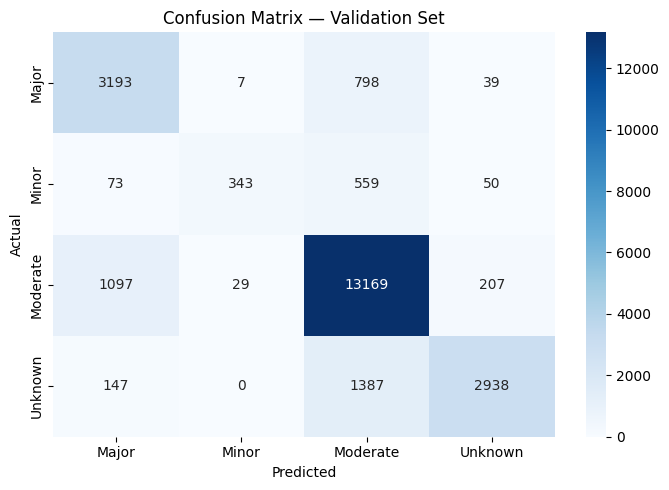

In [11]:
y_pred = model.predict(val_pool).flatten()

print(classification_report(y_val, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_val, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_, ax=ax
)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

## 10. Feature importance

C:\Users\sasas\AppData\Local\Temp\ipykernel_45004\488290490.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='importance', y='feature', palette='viridis', ax=ax)


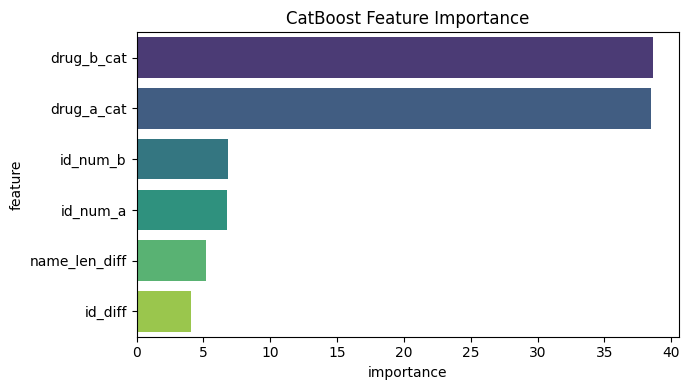

,feature,importance
3,drug_b_cat,38.666891
2,drug_a_cat,38.515501
1,id_num_b,6.813319
0,id_num_a,6.739470
4,name_len_diff,5.220359
5,id_diff,4.044461


In [12]:
importances = model.get_feature_importance(train_pool)
feat_df = pd.DataFrame({'feature': FEATURE_COLS, 'importance': importances}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=feat_df, x='importance', y='feature', palette='viridis', ax=ax)
ax.set_title('CatBoost Feature Importance')
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'feature_importance.png', dpi=150)
plt.show()
feat_df

## 11. Cross-validation (optional — takes a few minutes)

In [13]:
# Uncomment to run 5-fold CV
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
# scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
# print(f'CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}')

## 12. Save artifacts

In [14]:
model_path = ARTIFACTS_DIR / 'catboost_interaction.cbm'
le_path    = ARTIFACTS_DIR / 'label_encoder.joblib'
de_path    = ARTIFACTS_DIR / 'drug_encoder.joblib'

model.save_model(str(model_path))
joblib.dump(le,           le_path)
joblib.dump(drug_encoder, de_path)

print('Saved:')
print(' ', model_path)
print(' ', le_path)
print(' ', de_path)

Saved:
  ..\ml\artifacts\catboost_interaction.cbm
  ..\ml\artifacts\label_encoder.joblib
  ..\ml\artifacts\drug_encoder.joblib


## 13. Inference sanity check

In [15]:
import re

def predict_pair(drug_a: str, drug_b: str) -> dict:
    """Quick inference helper — mirrors MLService.predict logic."""
    def id_num(name):
        did = drug_encoder.get(name.lower(), 'DDInter0')
        m = re.search(r'\d+', did)
        return int(m.group()) if m else 0

    a_num = id_num(drug_a)
    b_num = id_num(drug_b)
    # Canonical ordering
    if a_num > b_num:
        drug_a, drug_b = drug_b, drug_a
        a_num, b_num   = b_num, a_num

    feat = [[a_num, b_num, drug_a.lower(), drug_b.lower(),
              abs(len(drug_a) - len(drug_b)), abs(a_num - b_num)]]

    proba = model.predict_proba(feat)[0]
    idx   = int(np.argmax(proba))
    label = le.inverse_transform([idx])[0]
    level_map = {'major': 'DANGER', 'moderate': 'CAUTION', 'minor': 'COMPATIBLE', 'unknown': 'UNKNOWN'}
    return {
        'drug_a': drug_a, 'drug_b': drug_b,
        'predicted_level': label,
        'risk': level_map.get(label.lower(), 'UNKNOWN'),
        'confidence': round(float(proba[idx]), 4),
        'all_proba': dict(zip(le.classes_, proba.round(4)))
    }

# Known pair from the DB — model should agree
result = predict_pair('Zidovudine', 'Chloroquine')
print(result)

{'drug_a': 'Zidovudine', 'drug_b': 'Chloroquine', 'predicted_level': 'Minor', 'risk': 'COMPATIBLE', 'confidence': 0.5129, 'all_proba': {'Major': 0.4497, 'Minor': 0.5129, 'Moderate': 0.0348, 'Unknown': 0.0025}}
